
# Hydrogen Atom: Numerical Solution of the Schrödinger Equation

## 1. Theoretical Background

### 1.1 The Hydrogen Atom Hamiltonian

We consider a hydrogen atom consisting of one electron and a fixed proton, within the non-relativistic Born–Oppenheimer approximation.

In SI units, the electronic Hamiltonian is

$$
\hat{H}
=
-\frac{\hbar^2}{2m_e}\nabla^2
-
\frac{e^2}{4\pi\epsilon_0 r}.
$$

The first term represents the kinetic energy of the electron, while the second describes the attractive Coulomb interaction between the electron and the proton.

Using **Hartree atomic units**, in which

$$
\hbar=m_e=e=\frac{1}{4\pi\epsilon_0}=1,
$$

the Hamiltonian simplifies to

$$
\boxed{
\hat{H}=-\frac{1}{2}\nabla^2-\frac{1}{r}
}
$$

The corresponding time-independent Schrödinger equation is

$$
\hat{H}\psi(\mathbf{r})=E\psi(\mathbf{r}),
$$

where:

- $\hat{H}$ is the Hamiltonian operator.
- $\psi(\mathbf{r})$ is the electronic wavefunction.
- $E$ is the corresponding energy eigenvalue.

Our objective is to solve this eigenvalue problem numerically and compare the results with the known analytical solution.


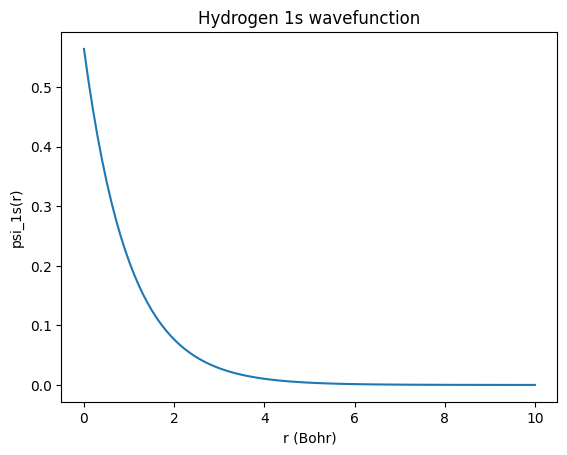

In [7]:

import numpy as np
import matplotlib.pyplot as plt

# Generate 100 evenly spaced radial coordinates
r = np.linspace(0, 10, 100)

# Exact hydrogen 1s wavefunction (atomic units)
psi = np.exp(-r) / np.sqrt(np.pi)

# Plot the wavefunction
plt.plot(r, psi)
plt.xlabel("r (Bohr)")
plt.ylabel("psi_1s(r)")
plt.title("Hydrogen 1s wavefunction")
plt.show()


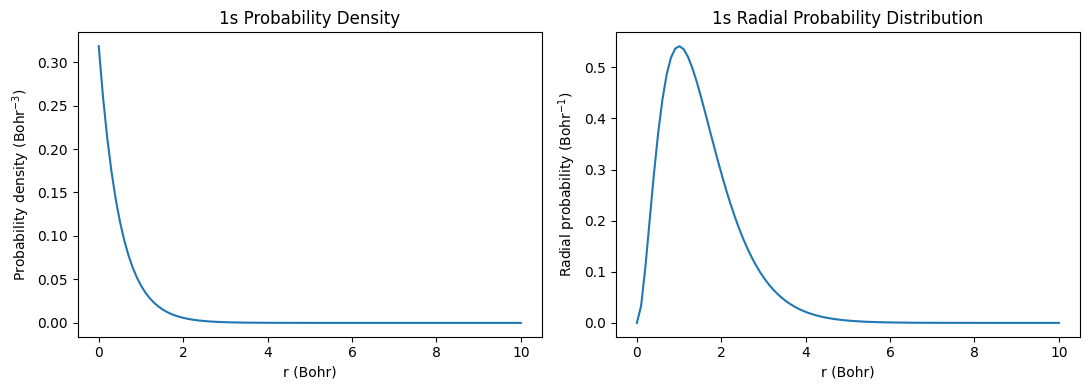

In [8]:

# Task 2: Probability distributions

# Probability density
rho = np.abs(psi)**2

# Radial probability distribution
P = 4 * np.pi * r**2 * rho

# Plot both quantities
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(r, rho)
axes[0].set_xlabel("r (Bohr)")
axes[0].set_ylabel("Probability density (Bohr$^{-3}$)")
axes[0].set_title("1s Probability Density")

axes[1].plot(r, P)
axes[1].set_xlabel("r (Bohr)")
axes[1].set_ylabel("Radial probability (Bohr$^{-1}$)")
axes[1].set_title("1s Radial Probability Distribution")

plt.tight_layout()
plt.show()


In [9]:
normalisation = np.trapezoid(P, r)
print("Normalisation =", normalisation)

Normalisation = 0.9999926255196632


In [10]:

# Task 3.1: Finite difference

h = 0.5

x_left = 0.5
x_center = 1.0
x_right = 1.5

# Our test function
def f(x):
    return x**2

# Evaluate the function at three grid points
u_left = f(x_left)
u_center = f(x_center)
u_right = f(x_right)

# Second-order central finite difference
second_derivative = (
    u_right - 2 * u_center + u_left
) / h**2

print("Numerical second derivative:", second_derivative)
print("Exact second derivative:", 2.0)


Numerical second derivative: 2.0
Exact second derivative: 2.0


In [11]:

import numpy as np

# Three internal grid points
N = 3
h = 1.0

r = h * np.arange(1, N + 1)

# Hamiltonian matrix
H = np.zeros((N, N))

for i in range(N):
    H[i, i] = 1 / h**2 - 1 / r[i]

    if i < N - 1:
        H[i, i+1] = -1 / (2 * h**2)
        H[i+1, i] = -1 / (2 * h**2)

print("Grid points:", r)
print("Hamiltonian:")
print(H)


Grid points: [1. 2. 3.]
Hamiltonian:
[[ 0.         -0.5         0.        ]
 [-0.5         0.5        -0.5       ]
 [ 0.         -0.5         0.66666667]]


In [12]:

from scipy.linalg import eigh_tridiagonal

# Define radial grid
N = 1000
r_max = 30.0

h = r_max / (N + 1)
r = h * np.arange(1, N + 1)

# Diagonal and off-diagonal matrix elements
diagonal = 1 / h**2 - 1 / r

off_diagonal = np.full(
    N - 1,
    -1 / (2 * h**2)
)

# Solve the eigenvalue problem
energies, eigenvectors = eigh_tridiagonal(
    diagonal,
    off_diagonal,
    select="i",
    select_range=(0, 2)
)

print("Numerical energies:")
print(energies)

print("\nExact hydrogen s-state energies:")
print([-0.5 / n**2 for n in range(1, 4)])


Numerical energies:
[-0.49988778 -0.12499298 -0.05542226]

Exact hydrogen s-state energies:
[-0.5, -0.125, -0.05555555555555555]


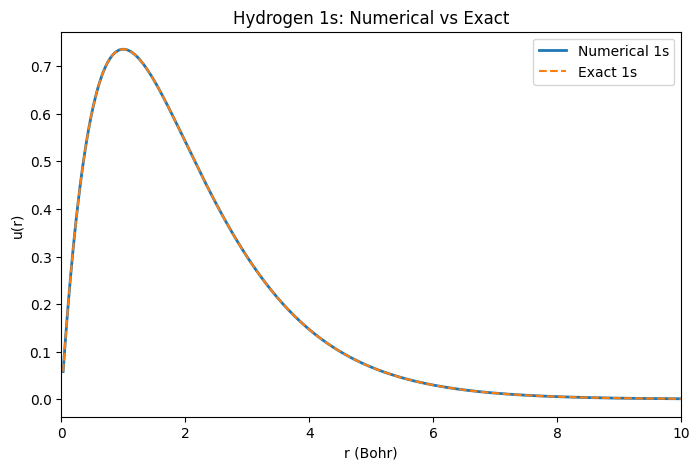

Numerical energy: -0.4998877750578385
Absolute energy error: 0.00011222494216150958


In [13]:

import matplotlib.pyplot as plt

# Numerical 1s radial wavefunction
u_numerical = eigenvectors[:, 0].copy()

# Convert discrete normalisation to integral normalisation
u_numerical /= np.sqrt(h)

# Exact analytical radial wavefunction
u_exact = 2 * r * np.exp(-r)

# Eigenvector signs are arbitrary
if np.dot(u_numerical, u_exact) < 0:
    u_numerical *= -1

# Compare numerical and exact solutions
plt.figure(figsize=(8, 5))

plt.plot(
    r,
    u_numerical,
    label="Numerical 1s",
    linewidth=2
)

plt.plot(
    r,
    u_exact,
    "--",
    label="Exact 1s"
)

plt.xlim(0, 10)
plt.xlabel("r (Bohr)")
plt.ylabel("u(r)")
plt.title("Hydrogen 1s: Numerical vs Exact")
plt.legend()
plt.show()

# Energy error
energy_error = abs(energies[0] - (-0.5))

print("Numerical energy:", energies[0])
print("Absolute energy error:", energy_error)


In [14]:

import numpy as np
from scipy.linalg import eigh_tridiagonal

def solve_hydrogen(N, r_max=30.0):
    """
    Solve the hydrogen radial equation for l=0.

    Parameters
    ----------
    N : int
        Number of internal grid points.
    r_max : float
        Maximum radial distance in Bohr.

    Returns
    -------
    h : float
        Grid spacing in Bohr.
    E : float
        Lowest eigenvalue in Hartree.
    """
    
    # Construct the radial grid
    h = r_max / (N + 1)
    r = h * np.arange(1, N + 1)

    # Hamiltonian matrix elements
    diagonal = 1 / h**2 - 1 / r
    off_diagonal = np.full(
        N - 1, -1 / (2 * h**2)
    )

    # Calculate the lowest eigenvalue
    energies = eigh_tridiagonal(
        diagonal,
        off_diagonal,
        eigvals_only=True,
        select="i",
        select_range=(0, 0)
    )

    return h, energies[0]


In [15]:

# Grid refinement study

N_values = [50, 100, 200, 400, 800, 1600]

exact_energy = -0.5

h_values = []
errors = []

for N in N_values:
    h, E = solve_hydrogen(N)

    error = abs(E - exact_energy)

    h_values.append(h)
    errors.append(error)

    print(
        f"N = {N:4d}, "
        f"h = {h:.5f}, "
        f"E = {E:.8f}, "
        f"Error = {error:.2e}"
    )


N =   50, h = 0.58824, E = -0.46292410, Error = 3.71e-02
N =  100, h = 0.29703, E = -0.48943289, Error = 1.06e-02
N =  200, h = 0.14925, E = -0.49724601, Error = 2.75e-03
N =  400, h = 0.07481, E = -0.49930233, Error = 6.98e-04
N =  800, h = 0.03745, E = -0.49982478, Error = 1.75e-04
N = 1600, h = 0.01874, E = -0.49995612, Error = 4.39e-05


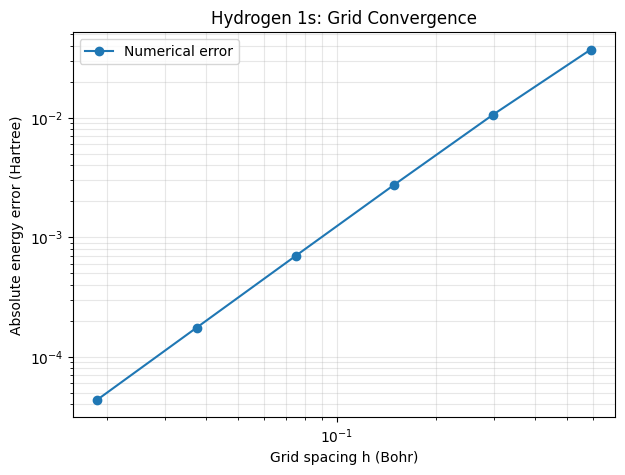

In [16]:

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.loglog(
    h_values,
    errors,
    "o-",
    label="Numerical error"
)

plt.xlabel("Grid spacing h (Bohr)")
plt.ylabel("Absolute energy error (Hartree)")
plt.title("Hydrogen 1s: Grid Convergence")
plt.legend()
plt.grid(True, which="both", alpha=0.3)

plt.show()


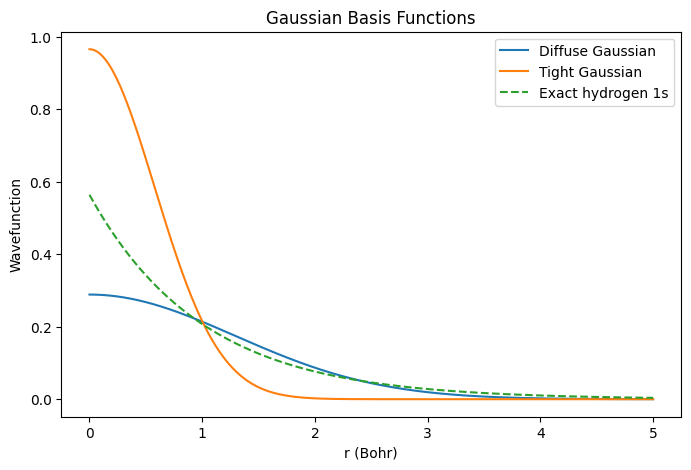

In [17]:

import numpy as np
import matplotlib.pyplot as plt

# Radial grid in atomic units
r = np.linspace(0, 5, 500)

# Two Gaussian exponents
alpha_1 = 0.3
alpha_2 = 1.5

# Primitive Gaussian normalisation
def gaussian(r, alpha):
    N = (2 * alpha / np.pi)**0.75
    return N * np.exp(-alpha * r**2)

chi_1 = gaussian(r, alpha_1)
chi_2 = gaussian(r, alpha_2)

# Exact hydrogen 1s orbital
psi_exact = np.exp(-r) / np.sqrt(np.pi)

plt.figure(figsize=(8, 5))

plt.plot(r, chi_1, label="Diffuse Gaussian")
plt.plot(r, chi_2, label="Tight Gaussian")
plt.plot(r, psi_exact, "--", label="Exact hydrogen 1s")

plt.xlabel("r (Bohr)")
plt.ylabel("Wavefunction")
plt.title("Gaussian Basis Functions")
plt.legend()
plt.show()


In [18]:

# Task 5.2: Overlap matrix

alpha = np.array([0.3, 1.5])

def overlap(a, b):
    return (
        2 * np.sqrt(a * b) / (a + b)
    )**1.5

# Construct the overlap matrix
S = np.zeros((2, 2))

for i in range(2):
    for j in range(2):
        S[i, j] = overlap(alpha[i], alpha[j])

print("Overlap matrix:")
print(S)


Overlap matrix:
[[1.         0.64349566]
 [0.64349566 1.        ]]


In [19]:

# Task 5.3: Construct the Hamiltonian matrix

alpha = np.array([0.3, 1.5])
N_basis = len(alpha)

# Normalisation constant
def norm(a):
    return (2 * a / np.pi)**0.75

# Kinetic energy integral
def kinetic(a, b):
    S_ab = overlap(a, b)
    return 3 * a * b / (a + b) * S_ab

# Nuclear attraction integral
def nuclear(a, b):
    p = a + b
    return -2 * np.pi * norm(a) * norm(b) / p

# Construct T and V matrices
T = np.zeros((N_basis, N_basis))
V = np.zeros((N_basis, N_basis))

for i in range(N_basis):
    for j in range(N_basis):
        T[i, j] = kinetic(alpha[i], alpha[j])
        V[i, j] = nuclear(alpha[i], alpha[j])

# Hamiltonian
H = T + V

print("Kinetic energy matrix:")
print(T)

print("\nNuclear attraction matrix:")
print(V)

print("\nHamiltonian matrix:")
print(H)


Kinetic energy matrix:
[[0.45       0.48262174]
 [0.48262174 2.25      ]]

Nuclear attraction matrix:
[[-0.87403874 -0.97417489]
 [-0.97417489 -1.95441005]]

Hamiltonian matrix:
[[-0.42403874 -0.49155315]
 [-0.49155315  0.29558995]]


In [20]:

from scipy.linalg import eigh

# Solve the generalized eigenvalue problem
energies, C = eigh(H, S)

print("Energy eigenvalues (Hartree):")
print(energies)

print("\nExpansion coefficients:")
print(C)

print("\nNumerical ground-state energy:")
print(energies[0])

print("\nExact ground-state energy:")
print(-0.5)

print("\nAbsolute energy error:")
print(abs(energies[0] + 0.5))


Energy eigenvalues (Hartree):
[-0.47054507  1.33104066]

Expansion coefficients:
[[-0.851939   -0.99042263]
 [-0.20989972  1.28944917]]

Numerical ground-state energy:
-0.47054507161299775

Exact ground-state energy:
-0.5

Absolute energy error:
0.029454928387002255


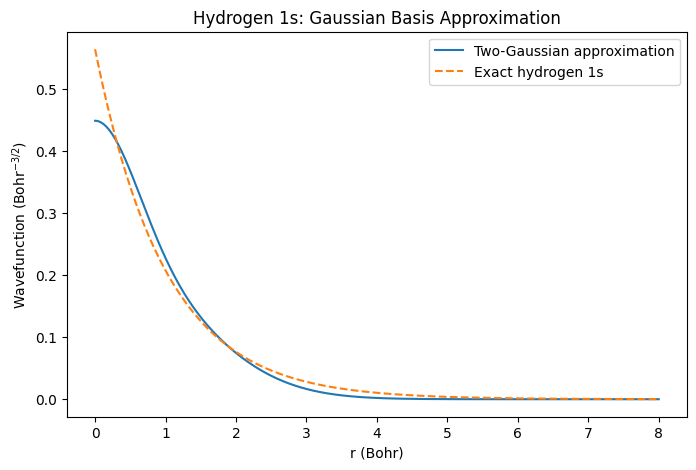

In [21]:

# Reconstruct the ground-state wavefunction

r = np.linspace(0, 8, 500)

chi_1 = gaussian(r, alpha[0])
chi_2 = gaussian(r, alpha[1])

# Ground-state expansion coefficients
c1, c2 = C[:, 0]

psi_approx = c1 * chi_1 + c2 * chi_2

# Exact hydrogen 1s wavefunction
psi_exact = np.exp(-r) / np.sqrt(np.pi)

# Eigenvectors have an arbitrary overall sign
if np.dot(psi_approx, psi_exact) < 0:
    psi_approx *= -1

plt.figure(figsize=(8, 5))

plt.plot(r, psi_approx, label="Two-Gaussian approximation")
plt.plot(r, psi_exact, "--", label="Exact hydrogen 1s")

plt.xlabel("r (Bohr)")
plt.ylabel("Wavefunction (Bohr$^{-3/2}$)")
plt.title("Hydrogen 1s: Gaussian Basis Approximation")
plt.legend()
plt.show()
